In [289]:
import os
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
import plotly.express as px


## Load data

In [290]:
features = pd.read_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/feature_based_data/three_class_raw_2s_ag.csv')
features.drop(['center_time', 'start_time', 'end_time'], axis= 1, inplace=True)


In [291]:
X = features.drop(columns=['label', 'experiment_id'])
y = features['label']

In [292]:
feature_names = X.columns


In [293]:
X.shape

(6203, 88)

In [294]:
y.shape

(6203,)

## PCA 

In [295]:
from sklearn.preprocessing import scale # Data scaling
from sklearn import decomposition #PCA

#### Data Scaling

In [296]:
X = scale(X)
X

array([[-0.95522613, -1.06466976,  1.35580219, ...,  1.95435498,
         1.19969336,  1.18772255],
       [-0.60498907, -1.29558928,  1.38498698, ...,  1.95435498,
         0.89494804,  0.8851703 ],
       [-0.42553771, -1.25188932,  1.31434485, ...,  1.95435498,
         0.56764361,  0.56022129],
       ...,
       [ 1.08964317,  0.76873607, -0.3813389 , ..., -0.43600276,
        -0.39589337, -0.39458052],
       [ 0.36143083,  1.14537906, -0.41918885, ..., -0.39141471,
        -0.37264255, -0.37110578],
       [ 0.36076966,  1.2256711 , -0.49516706, ..., -0.39141471,
        -0.37711495, -0.37562125]], shape=(6203, 88))

#### Perform PCA analysis

In [297]:
pca = decomposition.PCA(n_components=88)
pca.fit(X)

,n_components,88
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


#### Compute and retrieve the scores values

In [298]:
scores = pca.transform(X)

In [299]:
n_components = scores.shape[1]  # Get number of columns dynamically
scores_df = pd.DataFrame(scores, columns=[f'PC{i+1}' for i in range(n_components)])
scores_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC79,PC80,PC81,PC82,PC83,PC84,PC85,PC86,PC87,PC88
0,10.793972,-3.599658,-2.647616,0.340405,-0.396473,0.303789,1.710315,1.213479,2.545446,0.456845,...,3.610892e-13,5.522703e-13,-2.561115e-13,-8.238887e-14,3.375504e-11,-1.567284e-13,-8.724817e-13,-3.244758e-13,-6.683937e-13,1.298124e-13
1,9.561329,-3.392477,-2.548435,0.251082,-0.290719,-0.421555,1.731472,1.622188,2.702680,-0.143102,...,1.045376e-13,1.659142e-13,-1.472447e-14,6.740766e-14,6.590641e-12,-3.085416e-14,-2.052990e-13,-1.975656e-13,-1.568779e-13,-6.176598e-14
2,8.276651,-3.577963,-1.478267,0.147430,-1.423083,-0.224411,2.650096,1.679688,2.580937,-1.764014,...,9.238451e-14,7.322118e-14,2.500092e-14,9.843389e-14,1.814547e-12,-1.613958e-13,-1.233123e-13,-3.463165e-14,-1.412386e-13,-2.245396e-13
3,4.658670,-2.632088,-1.149334,0.984274,-1.015582,0.896448,3.243169,1.674047,1.861941,-1.321304,...,1.610014e-14,4.224313e-14,1.497969e-13,1.202252e-13,-6.426501e-12,-2.120958e-13,3.012738e-14,5.237774e-14,6.061388e-14,-2.859470e-13
4,-2.109632,0.569176,-0.794175,0.474662,0.372474,-0.649294,1.472848,-0.801146,1.179698,-0.204624,...,1.252132e-14,3.837619e-14,2.824299e-14,-7.175434e-14,2.265071e-12,-1.286133e-13,-4.004026e-14,7.777180e-14,-1.795538e-14,-9.237360e-15


In [300]:
df_scores = pd.concat([scores_df, y], axis=1)

In [301]:
df_scores.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC80,PC81,PC82,PC83,PC84,PC85,PC86,PC87,PC88,label
0,10.793972,-3.599658,-2.647616,0.340405,-0.396473,0.303789,1.710315,1.213479,2.545446,0.456845,...,5.522703e-13,-2.561115e-13,-8.238887e-14,3.375504e-11,-1.567284e-13,-8.724817e-13,-3.244758e-13,-6.683937e-13,1.298124e-13,pre-void
1,9.561329,-3.392477,-2.548435,0.251082,-0.290719,-0.421555,1.731472,1.622188,2.702680,-0.143102,...,1.659142e-13,-1.472447e-14,6.740766e-14,6.590641e-12,-3.085416e-14,-2.052990e-13,-1.975656e-13,-1.568779e-13,-6.176598e-14,pre-void
2,8.276651,-3.577963,-1.478267,0.147430,-1.423083,-0.224411,2.650096,1.679688,2.580937,-1.764014,...,7.322118e-14,2.500092e-14,9.843389e-14,1.814547e-12,-1.613958e-13,-1.233123e-13,-3.463165e-14,-1.412386e-13,-2.245396e-13,pre-void
3,4.658670,-2.632088,-1.149334,0.984274,-1.015582,0.896448,3.243169,1.674047,1.861941,-1.321304,...,4.224313e-14,1.497969e-13,1.202252e-13,-6.426501e-12,-2.120958e-13,3.012738e-14,5.237774e-14,6.061388e-14,-2.859470e-13,pre-void
4,-2.109632,0.569176,-0.794175,0.474662,0.372474,-0.649294,1.472848,-0.801146,1.179698,-0.204624,...,3.837619e-14,2.824299e-14,-7.175434e-14,2.265071e-12,-1.286133e-13,-4.004026e-14,7.777180e-14,-1.795538e-14,-9.237360e-15,pre-void


Retrieve loading values

In [302]:
loadings = pca.components_.T
df_loadings = pd.DataFrame(loadings, columns=[f'PC{i+1}' for i in range(n_components)], index=feature_names)
df_loadings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC79,PC80,PC81,PC82,PC83,PC84,PC85,PC86,PC87,PC88
acc_x_permutation_entropy,-0.080190,0.127140,-0.167638,0.119986,0.054286,0.001247,-0.045260,0.003772,-0.060906,-0.024992,...,-0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00
acc_x_spectral_entropy,-0.077294,0.140336,-0.158680,0.105983,0.054063,0.010733,-0.034918,-0.030645,-0.047501,0.021603,...,-8.808474e-15,-1.145596e-14,1.105530e-14,1.391017e-14,-2.718443e-13,8.635023e-15,6.973261e-15,-3.068392e-16,9.899654e-16,-1.263496e-14
acc_x_mean,-0.008155,-0.013920,-0.049633,-0.055679,-0.057381,0.250901,0.044447,-0.240349,0.614225,-0.026548,...,2.361692e-14,5.141951e-14,-1.435400e-14,-1.904793e-14,3.227217e-12,-6.296847e-15,-7.975347e-14,-5.789842e-15,-7.241533e-14,-8.771031e-15
acc_x_std,0.133800,-0.048220,-0.010692,0.008933,-0.149031,-0.091600,0.077827,-0.127102,-0.012998,0.036927,...,1.461595e-13,1.364986e-13,-3.607259e-14,-1.055369e-13,7.973151e-12,-1.391505e-13,-2.242069e-13,5.068752e-14,-1.049831e-13,1.631944e-13
acc_x_range,0.129999,-0.037442,-0.031485,0.001417,-0.151930,-0.093631,0.108155,-0.055455,0.016212,0.028124,...,2.187623e-01,1.574283e-01,1.435461e-01,-1.191996e-02,3.424088e-01,3.450604e-01,2.128778e-01,4.975354e-02,-1.188758e-01,-9.618607e-02


Explained variance for each PC

In [303]:
explained_variance = pca.explained_variance_ratio_
other_explained_variance = explained_variance
len(explained_variance)

88

## Scree plot

Preparing the explained variance data

Preparing the cumulative variance data

In [304]:

explained_variance = np.insert(explained_variance, 0, 0)


In [305]:
cumulative_variance = np.cumsum(np.round(explained_variance, decimals=3))


Combining the dataframe

In [306]:
n_components = len(pca.components_)
# pc_df = pd.DataFrame(['','PC1', 'PC2', 'PC3'], columns=['PC'])
pc_df = pd.DataFrame([''] + [f'PC{i+1}' for i in range(n_components)],columns=['PC'])
explained_variance_df = pd.DataFrame(explained_variance, columns=['Explained Variance'])
cumulative_variance_df = pd.DataFrame(cumulative_variance, columns=['Cumulative Variance'])


In [307]:
df_explained_variance = pd.concat([pc_df, explained_variance_df, cumulative_variance_df], axis=1)
df_explained_variance

,PC,Explained Variance,Cumulative Variance
0,,0.000000,0.000
1,PC1,0.491754,0.492
2,PC2,0.104138,0.596
3,PC3,0.086930,0.683
4,PC4,0.049598,0.733
...,...,...,...
84,PC84,0.000000,0.998
85,PC85,0.000000,0.998
86,PC86,0.000000,0.998
87,PC87,0.000000,0.998


Explained Variance

In [308]:
# https://plotly.com/python/bar-charts/

fig = px.bar(df_explained_variance, 
             x='PC', y='Explained Variance',
             text='Explained Variance',
             width=800)

fig.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig.show()

In [309]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df_explained_variance['PC'],
        y=df_explained_variance['Cumulative Variance'],
        marker=dict(size=15, color="LightSeaGreen")
    ))

fig.add_trace(
    go.Bar(
        x=df_explained_variance['PC'],
        y=df_explained_variance['Explained Variance'],
        marker=dict(color="RoyalBlue")
    ))

fig.show()

Explained Variance + Cumulative Variance

In [310]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(rows=1, cols=2)

fig.add_trace(
    go.Scatter(
        x=df_explained_variance['PC'],
        y=df_explained_variance['Cumulative Variance'],
        marker=dict(size=15, color="LightSeaGreen")
    ), row=1, col=1
    )

fig.add_trace(
    go.Bar(
        x=df_explained_variance['PC'],
        y=df_explained_variance['Explained Variance'],
        marker=dict(color="RoyalBlue"),
    ), row=1, col=2
    )

fig.show()

In [311]:
label = ['pre-void', 'void', 'post-void']
fig = px.scatter_3d(df_scores, x='PC1', y='PC2', z='PC3',
              color='label'
              )

fig.show()

In [312]:
loadings_label = df_loadings.index
# loadings_label = df_loadings.index.str.strip(' (cm)')

fig = px.scatter_3d(df_loadings, x='PC1', y='PC2', z='PC3',
                    text = loadings_label)

fig.show()

In [313]:
PC_number = np.arange(pca.n_components_) + 1 # Enumarate component numbers
print(len(PC_number))                                                         # Print component numbers

88


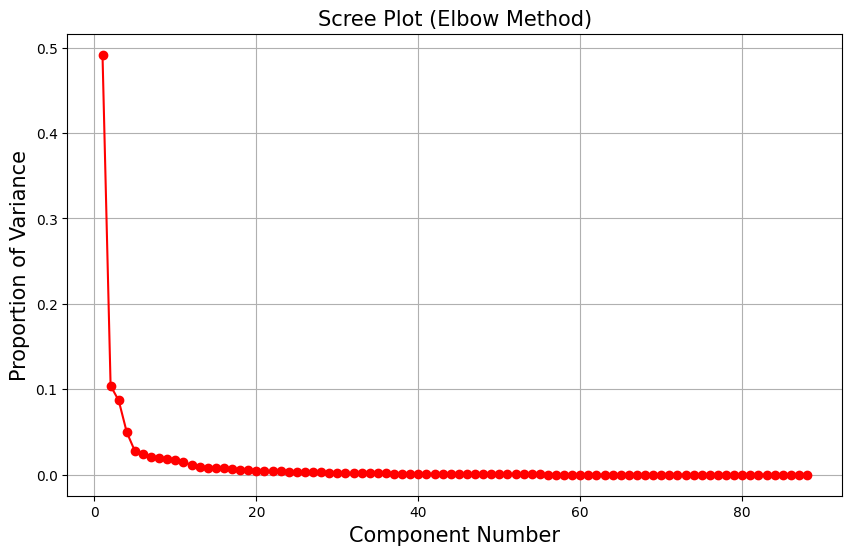

In [314]:
# Scree Plot
plt.figure(figsize=(10, 6))                           # Set figure and size
plt.plot(PC_number,                                   # Plot prop var
         other_explained_variance,
         'ro-')
plt.title('Scree Plot (Elbow Method)',       # Plot Annotations
          fontsize = 15)
plt.xlabel('Component Number',
           fontsize = 15)
plt.ylabel('Proportion of Variance',
           fontsize = 15)
plt.grid()                                                       # Add grid lines
plt.show()                                                    # Print graph

In [315]:
#Alternative Scree Plot Data
var = pca.explained_variance_                # Extract explained variance
print(var)                                                    # Print explained variance

[4.32813367e+01 9.16560459e+00 7.65109087e+00 4.36534393e+00
 2.43458904e+00 2.17226754e+00 1.84782676e+00 1.71154024e+00
 1.63628079e+00 1.48459599e+00 1.27723083e+00 1.03717626e+00
 7.59510351e-01 7.40668850e-01 7.27263713e-01 6.58923032e-01
 5.67935874e-01 5.16331048e-01 5.07708194e-01 4.13363014e-01
 3.77040424e-01 3.59260454e-01 3.32863580e-01 2.98405374e-01
 2.76751731e-01 2.72191623e-01 2.63536352e-01 2.38201576e-01
 2.13233804e-01 1.96970861e-01 1.79567438e-01 1.69280944e-01
 1.56390274e-01 1.47768013e-01 1.38306280e-01 1.27610288e-01
 1.23506235e-01 1.17558980e-01 1.16202526e-01 1.06763566e-01
 9.13237394e-02 8.71152764e-02 6.77394047e-02 6.12040875e-02
 5.65282467e-02 5.19675511e-02 4.80427737e-02 4.55155281e-02
 4.27637999e-02 3.69255209e-02 3.52613364e-02 3.35959325e-02
 3.10327812e-02 2.97502272e-02 2.56512831e-02 1.98239338e-02
 1.67997184e-02 1.21891877e-02 9.94156594e-03 7.43368650e-03
 7.18661490e-03 6.63533388e-03 6.42511181e-03 4.59221966e-03
 4.02451754e-03 2.862405

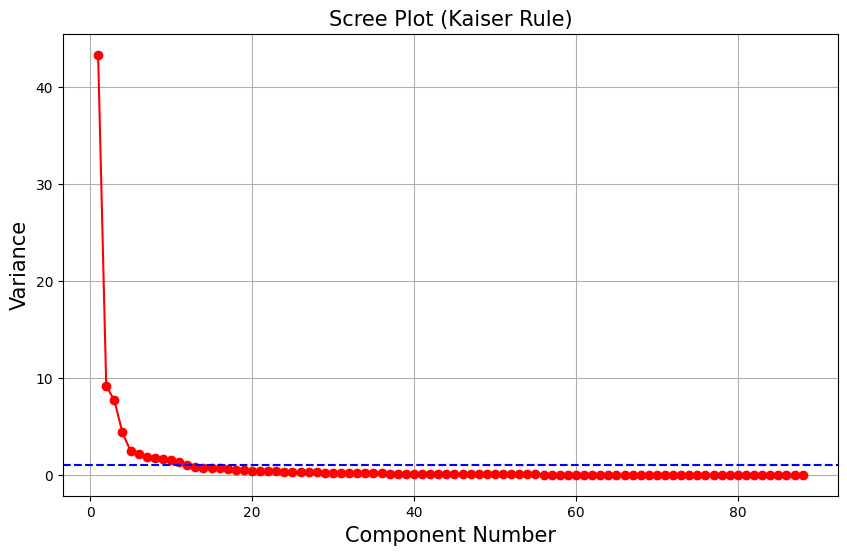

In [316]:
# Scree Plot
plt.figure(figsize=(10, 6))                           # Set figure and size
plt.plot(PC_number,                                   # Plot prop var
         var,
         'ro-')
plt.title('Scree Plot (Kaiser Rule)',       # Plot Annotations
          fontsize = 15)
plt.xlabel('Component Number',
           fontsize = 15)
plt.ylabel('Variance',
           fontsize = 15)
plt.axhline(
    y = 1,
    color = 'b',
    linestyle = '--'
)
plt.grid()                                                       # Add grid lines
plt.show() 